In [3]:
import gzip
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import os
import re
import shutil
import sys

In [57]:
from scipy.stats import spearmanr

## Fine-mapping based analysis

This section covers the analysis part that involves SuSIE fine mapping results that are provided directly by FinnGen.

In [25]:
work_dir = '/mnt/data/phenome_proj/finngen/susie/'

In [33]:
fg_files = [x for x in os.listdir(work_dir) if '.cred.sum' in x]

In [34]:
len(fg_files)

1302

In [197]:
group_by_icd = True
if group_by_icd:
    # Alternative way with ICD-10 codes
    matched_traits = 0
    icd_parent_codes = set()
    for susie_fname in fg_files:
        name_elements = susie_fname.split('_')
        if re.search("^[A-Z]+\d+$", name_elements[2]):
            matched_traits += 1
            icd_parent_codes.add(name_elements[2])
    icd_code_index = {val: idx for idx, val in enumerate(icd_parent_codes)}
    print(matched_traits)

    genes = defaultdict(lambda: list(np.zeros(len(icd_parent_codes))))
    for idx, susie_fname in enumerate(fg_files):
        icd_code = susie_fname.split('_')[2]
        if icd_code not in icd_parent_codes:
            continue
        this_icd_idx = icd_code_index[icd_code]
        gene_list = pd.read_csv(f'{work_dir}/{susie_fname}', sep='\t')['gene_most_severe']
        for gene in gene_list:
            if isinstance(gene, str):
                genes[gene][this_icd_idx] = 1
else:
    genes = defaultdict(lambda: list(np.zeros(len(fg_files))))
    for idx, susie_fname in enumerate(fg_files):
        gene_list = pd.read_csv(f'{work_dir}/{susie_fname}', sep='\t')['gene_most_severe']
        for gene in gene_list:
            if isinstance(gene, str):
                genes[gene][idx] = 1

1110


In [198]:
icd_parent_codes

{'AB1',
 'C3',
 'CD2',
 'D3',
 'E4',
 'F5',
 'G6',
 'H7',
 'H8',
 'I9',
 'J10',
 'K11',
 'L12',
 'M13',
 'N14',
 'O15',
 'P16',
 'Q17',
 'R18',
 'ST19',
 'U22',
 'VWXY20',
 'Z21'}

In [174]:
len(genes)a

4391

<AxesSubplot:ylabel='Count'>

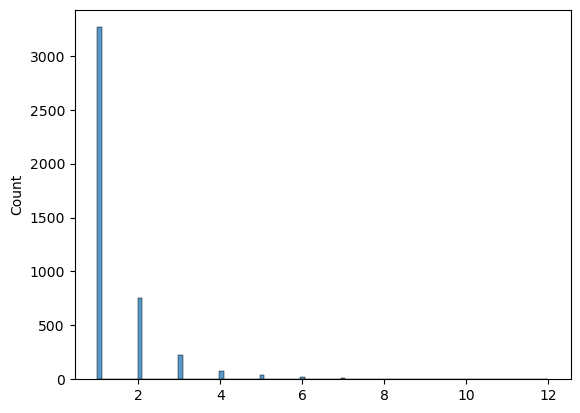

In [175]:
sns.histplot(pd.Series([sum(genes[x]) for x in genes]), bins=100)

In [176]:
assoc_counts = [sum(genes[x]) for x in genes]
for i in range(20):
    print(f'{i}: {len([x for x in assoc_counts if x > i])}')

0: 4391
1: 1126
2: 376
3: 152
4: 77
5: 37
6: 19
7: 10
8: 5
9: 3
10: 2
11: 1
12: 0
13: 0
14: 0
15: 0
16: 0
17: 0
18: 0
19: 0


In [177]:
gene_info = pd.read_csv('/mnt/data/phenome_proj/network_cleanup/gencode_formatted.bed', sep='\t', header=None)
gene_info.columns = ['chrom', 'start', 'end', 'gene_name']
gene_info.head()

,chrom,start,end,gene_name
0,1,11869,14412,DDX11L1
1,1,14363,29806,WASH7P
2,1,29554,31109,MIR1302-11
3,1,34554,36081,FAM138A
4,1,52473,54936,OR4G4P


In [178]:
gene_info.shape

(57820, 4)

In [179]:
gene_info = gene_info.drop_duplicates('gene_name')
gene_info.shape

(55765, 4)

In [180]:
annot_genes = set(gene_info['gene_name'])

In [181]:
Counter([x in annot_genes for x in list(genes.keys())])

Counter({False: 910, True: 3481})

In [182]:
fg_pleio_data = pd.DataFrame({'gene_name': list(genes.keys()), 
                             'fg_pleio_degree': list([sum(genes[x]) for x in genes])})
fg_pleio_data.head()

,gene_name,fg_pleio_degree
0,AL031281.2,3.0
1,SYNE1,2.0
2,GREB1,2.0
3,COL23A1,1.0
4,PKHD1L1,1.0


In [183]:
gene_info = gene_info.merge(fg_pleio_data, on='gene_name', how='outer')
gene_info.head()

,chrom,start,end,gene_name,fg_pleio_degree
0,1,11869.0,14412.0,DDX11L1,NaN
1,1,14363.0,29806.0,WASH7P,NaN
2,1,29554.0,31109.0,MIR1302-11,NaN
3,1,34554.0,36081.0,FAM138A,NaN
4,1,52473.0,54936.0,OR4G4P,NaN


In [184]:
sum(gene_info['fg_pleio_degree'] > 0)

4391

In [185]:
gene_info = gene_info[gene_info['fg_pleio_degree'] > 0]
gene_info.head()

,chrom,start,end,gene_name,fg_pleio_degree
86,1,1108436.0,1114935.0,TTLL10-AS1,1.0
90,1,1152288.0,1167411.0,SDF4,1.0
97,1,1227756.0,1244989.0,ACAP3,1.0
103,1,1270656.0,1284730.0,DVL1,2.0
104,1,1288069.0,1297157.0,MXRA8,1.0


In [186]:
pan_ukb_data = pd.read_csv('/mnt/data/phenome_proj/evolution/non_hla_panukb_pleiotropy_allTypes.tsv', sep='\t')
pan_ukb_data.head()

,gene_name,pleio_degree,pleio_degree_maxindep,pleio_degree_locuswide
0,RP3-469D22.1,NaN,NaN,7.0
1,AL031284.1,NaN,NaN,7.0
2,RHCE,6.0,2.0,7.0
3,TMEM57,5.0,6.0,7.0
4,TMEM61,NaN,NaN,1.0


In [187]:
all_gwas_data = gene_info.merge(pan_ukb_data, on='gene_name', how='outer')
all_gwas_data.shape

(19024, 8)

In [188]:
all_gwas_data['fg_pleio_degree'] = all_gwas_data['fg_pleio_degree'].replace({0: np.nan})

In [189]:
all_gwas_data.head()

,chrom,start,end,gene_name,fg_pleio_degree,pleio_degree,pleio_degree_maxindep,pleio_degree_locuswide
0,1,1108436.0,1114935.0,TTLL10-AS1,1.0,NaN,NaN,1.0
1,1,1152288.0,1167411.0,SDF4,1.0,NaN,NaN,NaN
2,1,1227756.0,1244989.0,ACAP3,1.0,NaN,NaN,1.0
3,1,1270656.0,1284730.0,DVL1,2.0,NaN,NaN,1.0
4,1,1288069.0,1297157.0,MXRA8,1.0,NaN,NaN,1.0


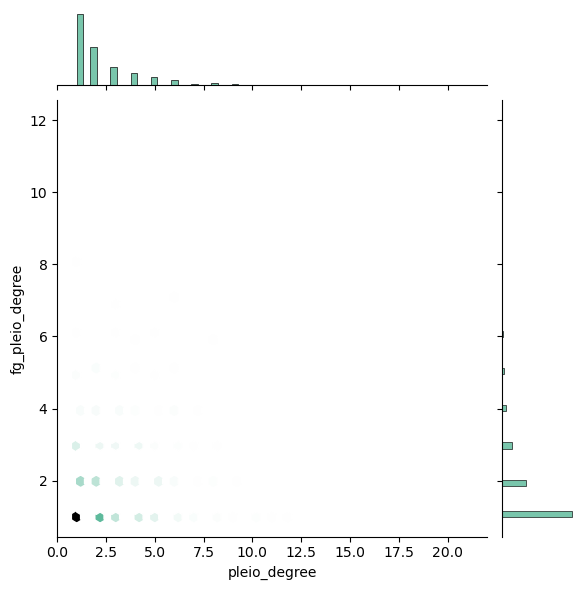

In [190]:
sns.jointplot(x=all_gwas_data['pleio_degree'], y=all_gwas_data['fg_pleio_degree'], 
              kind="hex", color="#4CB391")

In [191]:
spearmanr(all_gwas_data['pleio_degree'], all_gwas_data['fg_pleio_degree'], nan_policy='omit')

SpearmanrResult(correlation=0.2350300366025625, pvalue=2.0748741450463324e-20)

In [192]:
def hla_checker(gene_idx, gene_meta=all_gwas_data):
    try:
        this_gene = gene_meta.iloc[gene_idx]
#        print(this_gene)
    except:
        print(f'Error at idx {gene_idx}')
    if str(this_gene['chrom']) == '6' and this_gene['start'] > 27500000 and this_gene['end'] < 35000000:
        return False
    else:
#        print(type(this_gene['chr']))
        return True

In [193]:
Counter([hla_checker(x) for x in range(all_gwas_data.shape[0])])

Counter({True: 19016, False: 8})

In [194]:
all_gwas_non_hla = all_gwas_data.loc[[hla_checker(x) for x in range(all_gwas_data.shape[0])]]
all_gwas_non_hla.shape

(19016, 8)

In [195]:
all_gwas_non_hla.to_csv('/mnt/data/phenome_proj/evolution/non_hla_panukb_finngen_pleiotropy.tsv', sep='\t',
                       index=False)

## Closest gene-based analysis branch

Here, we attempt to use the strategy based on closest genes (the one that is similar to that used for pan-UKB data processing).

The coordinate conversion and clumping part has been performed using the `batch_process.sh` and `process_file.sh` scripts.

Below, we will perform gene inference and matrix construction.

In [207]:
import subprocess as sp

In [199]:
data_dir = '/mnt/data/phenome_proj/finngen/clumping/'
file_list = os.listdir(data_dir)
file_list = [x for x in file_list if x.endswith('.clumped')]

In [200]:
len(file_list)

906

In [201]:
file_list[0]

'finngen_R12_I9_CEREBAMY.clump.clumped'

In [210]:
def create_gene_bed(clump_file, work_dir=data_dir, data_dir=data_dir):
    bed_cmd = f'''awk 'OFS="\t" {{ print $1,$4,$4+1,$3,$5 }}' {data_dir}/{clump_file} \
                         | sort -k1,1 -k2,2n | grep -vP '^\s+|CHR' > {work_dir}/{clump_file}.lead.bed'''
    status = sp.run(bed_cmd, shell=True)
    gene_cmd = f'''bedtools closest -a {work_dir}/{clump_file}.lead.bed \
                                    -b /mnt/data/phenome_proj/network_cleanup/gencode_formatted.bed \
                                    > {work_dir}/{clump_file}.genes.bed'''
    status = sp.run(gene_cmd, shell=True)
    print(f'Done {clump_file}')

In [211]:
for clump_file in file_list:
    create_gene_bed(clump_file)

Done finngen_R12_I9_CEREBAMY.clump.clumped
Done finngen_R12_K11_IBD_STRICT_PSC.clump.clumped
Done finngen_R12_E4_PCOS.clump.clumped
Done finngen_R12_L12_SEBORRKERAT.clump.clumped
Done finngen_R12_CD2_BENIGN_PAROTID.clump.clumped
Done finngen_R12_H7_GLAUCOMA_POAG.clump.clumped
Done finngen_R12_M13_LUMBAR_PROLAPSE.clump.clumped
Done finngen_R12_M13_DORSOPATHY.clump.clumped
Done finngen_R12_H7_BLEPHAROCHALASIS.clump.clumped
Done finngen_R12_COPD_LATER.clump.clumped
Done finngen_R12_N14_PROSTHYPERPLA.clump.clumped
Done finngen_R12_H7_VITRBODYGLOBE.clump.clumped
Done finngen_R12_ABDOM_HERNIA.clump.clumped
Done finngen_R12_ALCOPANCCHRON.clump.clumped
Done finngen_R12_AB1_INTESTINAL_INFECTIONS.clump.clumped
Done finngen_R12_J10_CHRONSINUSITIS.clump.clumped
Done finngen_R12_I9_CHD.clump.clumped
Done finngen_R12_COPD_EARLY.clump.clumped
Done finngen_R12_RHEUMA_SEROPOS_STRICT.clump.clumped
Done finngen_R12_H8_VERTIGO.clump.clumped
Done finngen_R12_G6_ATROPHCIRCUM.clump.clumped
Done finngen_R12_Q

Done finngen_R12_CONGEN_HEART_ARTER.clump.clumped
Done finngen_R12_REITER.clump.clumped
Done finngen_R12_M13_MUSCLE.clump.clumped
Done finngen_R12_CD2_LYMPHOID_LEUKAEMIA_EXALLC.clump.clumped
Done finngen_R12_K11_LIVER.clump.clumped
Done finngen_R12_OTHER_SYSTCON_FG.clump.clumped
Done finngen_R12_F5_DELIRIUM.clump.clumped
Done finngen_R12_F5_ALLANXIOUS.clump.clumped
Done finngen_R12_K11_CHOLECYST.clump.clumped
Done finngen_R12_N14_ENDOMETRIOSIS_RECTPVAGSEPT_VAGINA.clump.clumped
Done finngen_R12_K11_OTHINFLIV.clump.clumped
Done finngen_R12_CD2_BENIGN_RECTUM.clump.clumped
Done finngen_R12_AB1_TUBERCULOSIS.clump.clumped
Done finngen_R12_E4_LACTONAS.clump.clumped
Done finngen_R12_F5_MOOD.clump.clumped
Done finngen_R12_E4_DYSPOLYGL.clump.clumped
Done finngen_R12_I9_PERICARD.clump.clumped
Done finngen_R12_Q17_CONGEN_MALFO_OVARIES_FALLOP_TUBES_BROAD_LIGAM.clump.clumped
Done finngen_R12_C3_BLADDER_EXALLC.clump.clumped
Done finngen_R12_J10_ASTHMACOPDKELA.clump.clumped
Done finngen_R12_Q17_VACTRE

Done finngen_R12_G6_MUSCOTHUNS.clump.clumped
Done finngen_R12_H7_RETIVASCOCCLUSION.clump.clumped
Done finngen_R12_MEMLOSS.clump.clumped
Done finngen_R12_I9_HEARTFAIL_AND_OVERWEIGHT.clump.clumped
Done finngen_R12_H7_GLAUCOMAMEDICATION.clump.clumped
Done finngen_R12_N14_CHRONKIDNEYDIS.clump.clumped
Done finngen_R12_N14_VULVAL_LSIL.clump.clumped
Done finngen_R12_CD2_HODGKIN_LYMPHOMA_EXALLC.clump.clumped
Done finngen_R12_CD2_PRIMARY_LYMPHOID_HEMATOPOIETIC_EXALLC.clump.clumped
Done finngen_R12_C3_COLORECTAL_EXALLC.clump.clumped
Done finngen_R12_CD2_BENIGN_COLORECANI.clump.clumped
Done finngen_R12_J10_BRONCHITIS.clump.clumped
Done finngen_R12_CD2_BENIGN_BRAIN_CNS.clump.clumped
Done finngen_R12_AB1_BACT_INTEST_OTH.clump.clumped
Done finngen_R12_AB1_WHOOPCOUGH.clump.clumped
Done finngen_R12_CD2_BENIGN_MENINGES.clump.clumped
Done finngen_R12_K11_ENERCOLNONINF.clump.clumped
Done finngen_R12_DERMATOPOLY_FG.clump.clumped
Done finngen_R12_O15_ABORT_MEDICAL.clump.clumped
Done finngen_R12_G6_MUSDYST.

Done finngen_R12_Q17_CLEFT_HARD_PALATE_NOS.clump.clumped
Done finngen_R12_L12_URTICA_NAS.clump.clumped
Done finngen_R12_I9_IHD.clump.clumped
Done finngen_R12_ILD_INSUFFICIENCY.clump.clumped
Done finngen_R12_M13_ARTHTROSIS_COX_PRIM_HIPSURG.clump.clumped
Done finngen_R12_M13_PALINDROMIC.clump.clumped
Done finngen_R12_BRONCHITIS.clump.clumped
Done finngen_R12_CD2_INSITU_BREAST_INTRADUCTAL_EXALLC.clump.clumped
Done finngen_R12_VD_MX.clump.clumped
Done finngen_R12_K11_OTHDIG.clump.clumped
Done finngen_R12_K11_HERNIA.clump.clumped
Done finngen_R12_HEIGHT_IRN.clump.clumped
Done finngen_R12_I9_SEQULAE.clump.clumped
Done finngen_R12_GOUT_STRICT.clump.clumped
Done finngen_R12_N14_MALEGEN.clump.clumped
Done finngen_R12_K11_ORAL_LICHEN_PLANUS.clump.clumped
Done finngen_R12_AD_LO_EXMORE.clump.clumped
Done finngen_R12_E4_NONTOXIC_THYROID.clump.clumped
Done finngen_R12_AB1_ZOSTER.clump.clumped
Done finngen_R12_E4_HYPERLIPMIX.clump.clumped
Done finngen_R12_L12_ROSACEANAS.clump.clumped
Done finngen_R12

Done finngen_R12_C3_BREAST_EXALLC.clump.clumped
Done finngen_R12_ASTHMA_CHILD_EXMORE.clump.clumped
Done finngen_R12_Q17_CONGEN_MALFO_CIRCULATO_SYSTEM.clump.clumped
Done finngen_R12_CD2_BENIGN_COLON.clump.clumped
Done finngen_R12_I9_VEINSOTH.clump.clumped
Done finngen_R12_L12_FOLLICULARCYST.clump.clumped
Done finngen_R12_L12_INFECT_SKIN.clump.clumped
Done finngen_R12_I9_DISVEINLYMPH.clump.clumped
Done finngen_R12_PD_DEMENTIA_EXMORE.clump.clumped
Done finngen_R12_AB1_VIRAL_SKIN_MUCOUS_MEMBRANE.clump.clumped
Done finngen_R12_L12_ULCERLOWLIMB.clump.clumped
Done finngen_R12_G6_MIGRAINE_WITH_AURA.clump.clumped
Done finngen_R12_Q17_ANKYLOGLOSSIA.clump.clumped
Done finngen_R12_C3_COLON_ADENO_EXALLC.clump.clumped
Done finngen_R12_M13_FIBROBLASTIC.clump.clumped
Done finngen_R12_M13_SPONDYLOPATHY.clump.clumped
Done finngen_R12_M13_GANGLION.clump.clumped
Done finngen_R12_G6_NEUATR.clump.clumped
Done finngen_R12_H8_EXTERNAL.clump.clumped
Done finngen_R12_O15_DELIV_PERIN_LACER.clump.clumped
Done fin

Done finngen_R12_CD2_BENIGN_LIPOMATOUS.clump.clumped
Done finngen_R12_M13_SCOLIOSIS.clump.clumped
Done finngen_R12_M13_ARTHTROSIS_COX_PRIM_ICD10.clump.clumped
Done finngen_R12_I9_STR.clump.clumped
Done finngen_R12_N14_ENDOMETRIOSIS_NOS.clump.clumped
Done finngen_R12_CD2_BENIGN_CAECUM.clump.clumped
Done finngen_R12_K11_CHOLECYSTECTOMY.clump.clumped
Done finngen_R12_M13_MYOSITIS.clump.clumped
Done finngen_R12_Q17_NEUROFIBROMATOSIS_2.clump.clumped
Done finngen_R12_M13_DORSALGIA.clump.clumped
Done finngen_R12_M13_ENTEROARTHR.clump.clumped
Done finngen_R12_O15_EXCESS_VOMIT_PREG.clump.clumped
Done finngen_R12_C3_KIDNEY_CLEAR_CELL_CARCINOMA_EXALLC.clump.clumped
Done finngen_R12_H7_CATARACTOTHER.clump.clumped
Done finngen_R12_RX_STATIN.clump.clumped
Done finngen_R12_I9_TIA.clump.clumped
Done finngen_R12_M13_ANKYLOSPON.clump.clumped
Done finngen_R12_H7_LACRIMALSYSTEM.clump.clumped
Done finngen_R12_F5_DEMENTIA_INCLAVO.clump.clumped
Done finngen_R12_N14_URETHRAOTH.clump.clumped
Done finngen_R12_F

In [214]:
matched_traits = 0
icd_parent_codes = set()
for clump_file_name in file_list:
    name_elements = clump_file_name.split('_')
    if re.search("^[A-Z]+\d+$", name_elements[2]):
        matched_traits += 1
        icd_parent_codes.add(name_elements[2])
icd_code_index = {val: idx for idx, val in enumerate(icd_parent_codes)}
print(matched_traits)

742


In [216]:
icd_parent_codes

{'AB1',
 'C3',
 'CD2',
 'D3',
 'E4',
 'F5',
 'G6',
 'H7',
 'H8',
 'I9',
 'J10',
 'K11',
 'L12',
 'M13',
 'N14',
 'O15',
 'Q17',
 'R18',
 'ST19',
 'U22',
 'Z21'}

In [217]:
genes = {}
for idx, pheno in enumerate(file_list):
    in_file = f'{work_dir}/{pheno}.genes.bed'
    try:
        gene_data = pd.read_csv(in_file, sep='\t', header=None)
    except:
#        print('Broke here')
        continue
    name_elements = pheno.split('_')
    if re.search("^[A-Z]+\d+$", name_elements[2]):
        current_icd_code = name_elements[2]
        current_icd_idx = icd_code_index[current_icd_code]
    gene_data.columns = ['var_chr', 'var_pos', 'var_end', 'rsid', 'pval', 'chr', 'start', 'end', 'gene_name']
    for chrom, start, end, symbol in zip(gene_data['chr'], gene_data['start'], 
                          gene_data['end'], gene_data['gene_name']):
        if symbol not in genes:
            genes[symbol] = [symbol, chrom, start, end] + [0 for x in icd_parent_codes]
        genes[symbol][current_icd_idx + 4] = 1
print(len(genes))
print(genes['LRP1'])
print(len(genes['LRP1']))

8289
['LRP1', 12, 57522276, 57607134, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1]
25


<AxesSubplot:ylabel='Count'>

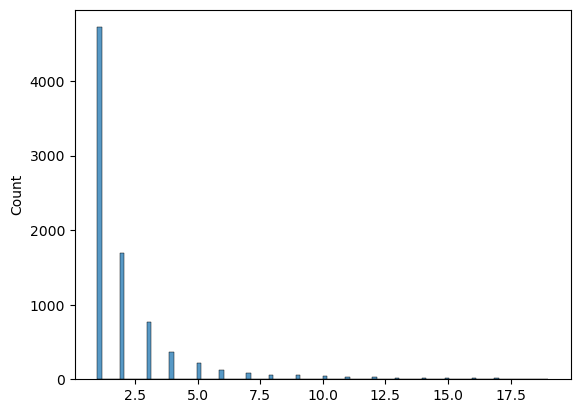

In [218]:
sns.histplot(pd.Series([sum(genes[x][4:]) for x in genes]), bins=100)

In [220]:
all_genes = list(genes.values())
gene_matrix = np.array([x[4:] for x in all_genes])
gene_matrix

array([[1, 0, 0, ..., 1, 0, 0],
       [1, 0, 0, ..., 1, 1, 0],
       [1, 0, 0, ..., 1, 1, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [221]:
gene_meta = {'gene_name': [x[0] for x in all_genes],
            'chr': [x[1] for x in all_genes],
            'start': [x[2] for x in all_genes],
            'end': [x[3] for x in all_genes]}
gene_meta = pd.DataFrame(gene_meta)
gene_meta.head()

,gene_name,chr,start,end
0,APOC1,19,45417504,45422606
1,ZNF184,6,27418522,27440897
2,ZSCAN31,6,28292470,28324048
3,RPSAP2,6,28699794,28700681
4,GABBR1,6,29523406,29601753


In [222]:
def hla_checker(gene_idx, gene_meta=gene_meta):
    try:
        this_gene = gene_meta.iloc[gene_idx]
#        print(this_gene)
    except:
        print(f'Error at idx {gene_idx}')
    if str(this_gene['chr']) == '6' and this_gene['start'] > 27500000 and this_gene['end'] < 35000000:
        return False
    else:
#        print(type(this_gene['chr']))
        return True

In [224]:
Counter([hla_checker(x) for x in range(len(gene_matrix))])

Counter({True: 7919, False: 370})

In [225]:
non_hla_genes = [idx for idx, gene in enumerate(gene_matrix) if hla_checker(idx)]
len(non_hla_genes)

7919

In [227]:
non_hla_matrix = gene_matrix[non_hla_genes, :]

In [228]:
non_hla_matrix.shape

(7919, 21)

In [234]:
non_hla_meta = gene_meta.iloc[non_hla_genes, :].copy()

In [235]:
non_hla_meta.shape

(7919, 4)

In [236]:
non_hla_meta['fg_pleio_degree_closest'] = np.apply_along_axis(sum, 1, non_hla_matrix)

In [237]:
non_hla_meta.head()

,gene_name,chr,start,end,fg_pleio_degree_closest
0,APOC1,19,45417504,45422606,5
1,ZNF184,6,27418522,27440897,10
33,THADA,2,43393800,43823185,10
34,ERBB4,2,212240446,213403565,5
35,TTC28,22,28374004,29075853,7


In [238]:
all_gwas_data.shape

(19024, 8)

In [279]:
all_gwas_data_final = all_gwas_non_hla.merge(non_hla_meta, 
                                        on='gene_name', how='outer')

In [280]:
all_gwas_data_final.shape

(21631, 9)

In [282]:
all_gwas_data_final.chrom = all_gwas_data_final.chrom.astype('string')
all_gwas_data_final.chr = all_gwas_data_final.chr.astype('string')

In [283]:
all_gwas_data_final['start'] = [y if np.isnan(x) else x for x, y in zip(all_gwas_data_final['start_x'],
                all_gwas_data_final['start_y'])]
all_gwas_data_final['end'] = [y if np.isnan(x) else x for x, y in zip(all_gwas_data_final['end_x'],
                all_gwas_data_final['end_y'])]
all_gwas_data_final['chrom'] = [y if pd.isnull(x) else x for x, y in zip(all_gwas_data_final['chrom'],
                all_gwas_data_final['chr'])]
all_gwas_data_final = all_gwas_data_final.drop(['start_x', 'start_y', 'end_x', 'end_y', 'chr'],
                                          axis=1)
all_gwas_data_final.tail()

,chrom,gene_name,fg_pleio_degree,pleio_degree,pleio_degree_maxindep,pleio_degree_locuswide,fg_pleio_degree_closest,start,end
21618,14.0,RNU6ATAC28P,NaN,NaN,NaN,NaN,1.0,84216728.0,84216845.0
21619,7.0,AC004166.6,NaN,NaN,NaN,NaN,1.0,74320406.0,74331163.0
21620,10.0,ANAPC16,NaN,NaN,NaN,NaN,1.0,73975787.0,73995618.0
21621,10.0,C10orf55,NaN,NaN,NaN,NaN,1.0,75669727.0,75682535.0
21622,15.0,CTSH,NaN,NaN,NaN,NaN,1.0,79213400.0,79241916.0


In [284]:
all_gwas_data_final.head()

,chrom,gene_name,fg_pleio_degree,pleio_degree,pleio_degree_maxindep,pleio_degree_locuswide,fg_pleio_degree_closest,start,end
0,1,TTLL10-AS1,1.0,NaN,NaN,1.0,NaN,1108436.0,1114935.0
1,1,SDF4,1.0,NaN,NaN,NaN,NaN,1152288.0,1167411.0
2,1,ACAP3,1.0,NaN,NaN,1.0,2.0,1227756.0,1244989.0
3,1,DVL1,2.0,NaN,NaN,1.0,NaN,1270656.0,1284730.0
4,1,MXRA8,1.0,NaN,NaN,1.0,2.0,1288069.0,1297157.0


In [285]:
Counter([pd.isnull(x) for x in all_gwas_data_final['chrom']])

Counter({False: 9113, True: 12510})

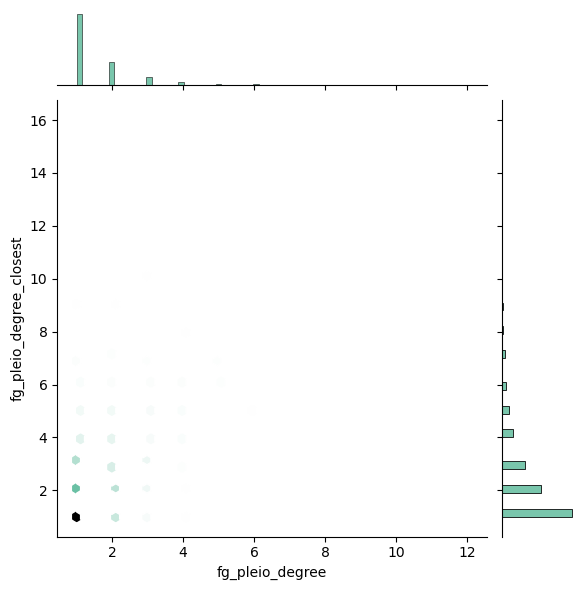

In [286]:
sns.jointplot(x=all_gwas_data_final['fg_pleio_degree'], 
              y=all_gwas_data_final['fg_pleio_degree_closest'], 
              kind="hex", color="#4CB391")

In [290]:
export_gwas = all_gwas_data_final.drop(['chrom', 'start', 'end'], axis=1)
export_gwas.shape

(21623, 6)

In [291]:
export_gwas.drop_duplicates('gene_name', inplace=True)
export_gwas.shape

(21623, 6)

### NB!

Here I rename the columns in the export data frame so that the main FinnGen data column contains closest gene data (and the fine-mapping based column has a different suffix).

This decision is motivated by exploratory analysis and comparison of the reulsts obtained using these two methods (closest gene-based method yields results that are more consistent with the pan-UKB analysis).

In [294]:
export_gwas = export_gwas.rename({'fg_pleio_degree': 'fg_pleio_degree_finemap',
                   'fg_pleio_degree_closest': 'fg_pleio_degree'}, axis=1)

In [295]:
export_gwas.to_csv('/mnt/data/phenome_proj/evolution/non_hla_panukb_finngen_pleiotropy_final.tsv', sep='\t', index=False)

### Exporting the bipartite network for modularity analysis

In [296]:
gene_matrix.shape

(8289, 21)

In [297]:
icd_code_index

{'M13': 0,
 'Q17': 1,
 'H8': 2,
 'D3': 3,
 'U22': 4,
 'O15': 5,
 'G6': 6,
 'I9': 7,
 'J10': 8,
 'F5': 9,
 'AB1': 10,
 'R18': 11,
 'CD2': 12,
 'H7': 13,
 'K11': 14,
 'Z21': 15,
 'N14': 16,
 'ST19': 17,
 'E4': 18,
 'L12': 19,
 'C3': 20}

In [300]:
icd_code_list = icd_code_index.keys()
with open('/mnt/data/phenome_proj/evolution/finngen_closest_edgeList.txt', 'w') as net_file:
    for idx, row_data in enumerate(gene_matrix):
        for col_idx, assoc in enumerate(row_data):
            if assoc == 1:
                net_file.write(f'{idx}\t{col_idx}\n')